# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

# Normal Base Line

In [2]:
# Load 97.mat file
data = loadmat('97.mat')

# View available variables
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


# Load Signal Function

In [3]:
def load_cwru_signal(filename, variable_name):

    data = loadmat(filename)

    signal = data[variable_name]

    signal = signal.flatten()

    return signal

# Load Example Signal

In [4]:
normal_signal = load_cwru_signal(
    "97.mat",
    "X097_DE_time"
)

print(normal_signal.shape)

(243938,)


## Why Windowing?

Machine learning algorithms cannot use an entire vibration signal directly.

Therefore, the signal is divided into smaller segments (windows).

Window Size = 1024 samples

Step Size = 512 samples

This creates overlapping windows and increases the number of training samples.

# Create Window Function

In [5]:
def create_windows(
    signal,
    window_size=1024,
    step_size=512
):

    windows = []

    for start in range(
        0,
        len(signal) - window_size,
        step_size
    ):

        end = start + window_size

        window = signal[start:end]

        windows.append(window)

    return np.array(windows)

# Apply Windowing

In [6]:
normal_windows = create_windows(
    normal_signal,
    window_size=1024,
    step_size=512
)

print(normal_windows.shape)

(475, 1024)


# Explain Output
### Interpretation

474 = Number of windows

1024 = Samples per window

Each row now represents one machine-learning observation.

# Plot First Window

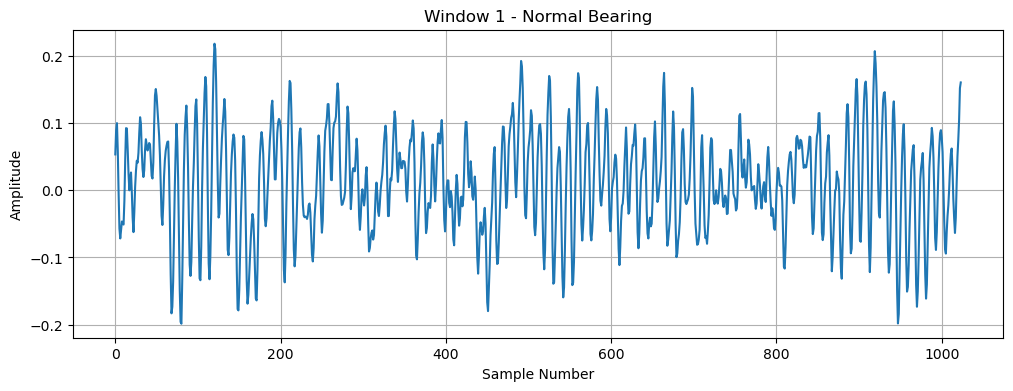

In [7]:
plt.figure(figsize=(12,4))

plt.plot(
    normal_windows[0]
)

plt.title(
    "Window 1 - Normal Bearing"
)

plt.xlabel(
    "Sample Number"
)

plt.ylabel(
    "Amplitude"
)

plt.grid(True)

plt.show()

# Plot Second Window

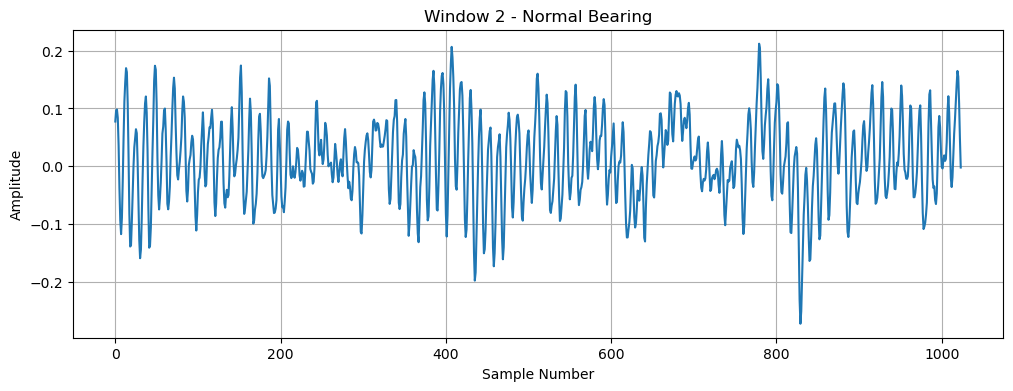

In [8]:
plt.figure(figsize=(12,4))

plt.plot(
    normal_windows[1]
)

plt.title(
    "Window 2 - Normal Bearing"
)

plt.xlabel(
    "Sample Number"
)

plt.ylabel(
    "Amplitude"
)

plt.grid(True)

plt.show()

# Compare Overlap

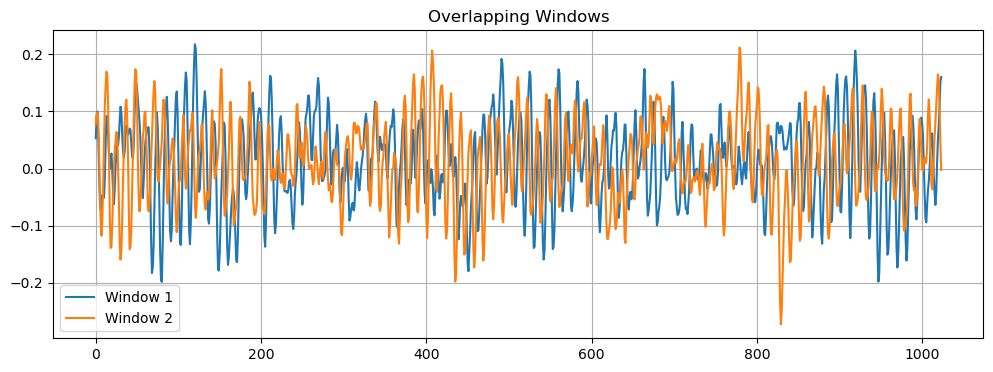

In [9]:
plt.figure(figsize=(12,4))

plt.plot(
    normal_windows[0],
    label="Window 1"
)

plt.plot(
    normal_windows[1],
    label="Window 2"
)

plt.legend()

plt.title(
    "Overlapping Windows"
)

plt.grid(True)

plt.show()

# Window All Bearing Classes

In [11]:
inner_signal = load_cwru_signal(
    "105.mat",
    "X105_DE_time"
)

ball_signal = load_cwru_signal(
    "118.mat",
    "X118_DE_time"
)

outer_signal = load_cwru_signal(
    "130.mat",
    "X130_DE_time"
)

# Create Windows for All Classes

In [13]:
normal_windows = create_windows(normal_signal)

inner_windows = create_windows(inner_signal)

ball_windows = create_windows(ball_signal)

outer_windows = create_windows(outer_signal)

# Count Windows

In [14]:
print("Normal :", len(normal_windows))

print("Inner :", len(inner_windows))

print("Ball :", len(ball_windows))

print("Outer :", len(outer_windows))

Normal : 475
Inner : 235
Ball : 238
Outer : 237


# Create Summary Table

In [15]:
window_summary = pd.DataFrame({

    "Condition":[
        "Normal",
        "Inner Race",
        "Ball Fault",
        "Outer Race"
    ],

    "Number of Windows":[
        len(normal_windows),
        len(inner_windows),
        len(ball_windows),
        len(outer_windows)
    ]
})

window_summary

,Condition,Number of Windows
0,Normal,475
1,Inner Race,235
2,Ball Fault,238
3,Outer Race,237


# Save Windows Information

In [16]:
window_summary.to_csv(
    "window_summary.csv",
    index=False
)

# Save Window Metadata

In [17]:
window_metadata = pd.DataFrame({
    "Source_File": [
        "97.mat",
        "98.mat",
        "99.mat",
        "100.mat",
        "105.mat",
        "106.mat",
        "107.mat",
        "108.mat",
        "118.mat",
        "119.mat",
        "120.mat",
        "121.mat",
        "130.mat",
        "131.mat",
        "132.mat",
        "133.mat"
    ]
})

window_metadata

,Source_File
0,97.mat
1,98.mat
2,99.mat
3,100.mat
4,105.mat
5,106.mat
6,107.mat
7,108.mat
8,118.mat
9,119.mat
